/media/aris/Data/master2025dev/aris_master/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|██████████| 50/50 [00:03<00:00, 14.62it/s]


(512, 512)


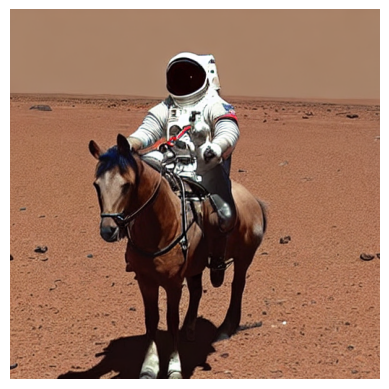

In [1]:
from diffusers import StableDiffusionPipeline
import torch

model_path = "/media/aris/Data/master2025dev/ckpts/stable-diffusion-v1-5"
pipe = StableDiffusionPipeline.from_pretrained(model_path, torch_dtype=torch.float16)
pipe = pipe.to("cuda")

prompt = "a photo of an astronaut riding a horse on mars"
image = pipe(prompt).images[0]  

#print image dimensions
print(image.size)

#plot image
import matplotlib.pyplot as plt
plt.imshow(image)
plt.axis("off")
plt.show()

In [ ]:
tokenizer = pipe.tokenizer
prompt = "a photo of x"

tokens = tokenizer(prompt, return_tensors="pt").input_ids
print(tokens)

#embedding
text_encoder = pipe.text_encoder
with torch.no_grad():
    text_embeddings = text_encoder(tokens.to("cuda"))[0]
print(text_embeddings.shape)

#Feature extractor
feature_extractor = pipe.feature_extractor
image_input = feature_extractor(images=image, return_tensors="pt").pixel_values.to("cuda")
print(image_input.shape)
print(pipe) 

tensor([[49406,   320,  1125,   539,   343, 49407]])
torch.Size([1, 6, 768])
torch.Size([1, 3, 224, 224])
StableDiffusionPipeline {
  "_class_name": "StableDiffusionPipeline",
  "_diffusers_version": "0.36.0",
  "_name_or_path": "/media/aris/Data/master2025dev/ckpts/stable-diffusion-v1-5",
  "feature_extractor": [
    "transformers",
    "CLIPImageProcessor"
  ],
  "image_encoder": [
    null,
    null
  ],
  "requires_safety_checker": true,
  "safety_checker": [
    "stable_diffusion",
    "StableDiffusionSafetyChecker"
  ],
  "scheduler": [
    "diffusers",
    "PNDMScheduler"
  ],
  "text_encoder": [
    "transformers",
    "CLIPTextModel"
  ],
  "tokenizer": [
    "transformers",
    "CLIPTokenizer"
  ],
  "unet": [
    "diffusers",
    "UNet2DConditionModel"
  ],
  "vae": [
    "diffusers",
    "AutoencoderKL"
  ]
}

